**1. Analyse du programme**

* **Dataset** : `images_chiffres_codees_niveau_de_gris.csv`
* **Input** : Les pixels de l'image.
* **Output** : Le chiffre prédit (Label entre 0 et 9).
* **Technique utilisée** : Arbre de décision (`DecisionTreeClassifier`).

**2. Étapes de Machine Learning identifiées**

1.  **Chargement des données** (`read_csv`).
2.  **Préparation (Split)** : Séparation des données en ensemble d'entraînement (`0:21000`) et de test (`21000:`).
3.  **Entraînement (Training)** : Ajustement du modèle sur les données d'entraînement (`clf.fit`).
4.  **Test (Testing)** : Prédiction sur les données de test (`clf.predict`).
5.  **Évaluation** : Comparaison des prédictions avec les vraies valeurs pour calculer la précision.

**3. Mesure de performance**

* **Précision** : Le taux de prédictions correctes.

**4. Objectif des lignes 18 à 23**

* Ces lignes introduisent du **bruit aléatoire** dans une image de test (modification de la valeur de 100 pixels au hasard) pour tester la robustesse du modèle face à des données altérées.

**5. Exécution et test du programme**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

In [2]:
data = pd.read_csv('images_chiffres_codees_niveau_de_gris.csv').to_numpy()
data

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [3, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [7, 0, 0, ..., 0, 0, 0]], shape=(2559, 785))

In [3]:
clf = DecisionTreeClassifier()

In [4]:
x = data[0:2100, 1:]
label = data[0:2100, 0]

In [5]:
clf.fit(x, label)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [6]:
xtest = data[2100: ,1:]
actual_label = data[2100: ,0]
p = clf.predict(xtest)

In [7]:
len(p)

459

In [8]:
count=0
for i in range(0,len(p)):
    count+=1 if p[i]==actual_label[i] else 0
print(f"Accuracy= {(count/len(p))*100:.4} %")

Accuracy= 75.6 %


In [9]:
d = xtest[5]

In [10]:
nombre_de_pixels_errones = 100
for i in range(nombre_de_pixels_errones):
    position = np.random.randint(0, 784, 1)[0]
    bruit = np.random.randint(-200, 200, 1)[0]
    d[position] += bruit
    d[position] = d[position] % 255

print(clf.predict([d]))

[2]


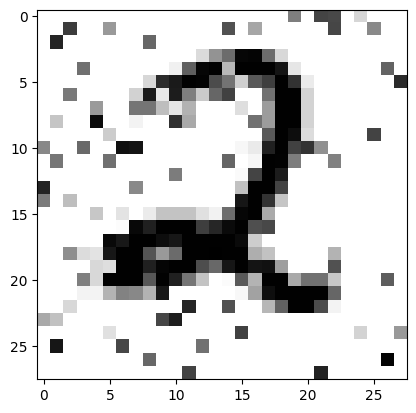

In [11]:
d.shape = (28, 28)
plt.imshow(255 - d, cmap='gray')
plt.show()